## 📊 Monte Carlo Simulation
###### Originating from statistical physics and finance, Monte Carlo methods are numerical algorithms for computing stochastic expectations via random sampling. They rely on the law of large numbers, which guarantees convergence to the true expectation, and the central limit theorem, which guarantees a convergence rate of order

In [27]:
!pip install pandas numpy yfinance matplotlib
from IPython.display import clear_output
clear_output()
import pandas as pd, numpy as np, yfinance as yf, matplotlib.pyplot as plt, scipy.stats as stats, seaborn as sns
from datetime import datetime


In [28]:
# Set Ticker and date
ticker = 'TOTS3.SA'
today_str = datetime.now().strftime('%Y-%m-%d')

In [29]:
# Price Data
asset = f'{ticker}'
stock = yf.download(asset, start='2018-01-01', end=today_str, auto_adjust='False')
#stock = stock[['Close']].copy()

# Remove ticker name from columns
if isinstance(stock.columns, pd.MultiIndex):
    stock.columns = stock.columns.get_level_values(0)

stock['Return'] = stock['Close'].pct_change()
stock.dropna(inplace=True) # Remove NaN
stock.sort_index(ascending=True, inplace=True)
stock.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Return
Date,,,,,,
2026-05-11,33.500000,35.000000,33.209999,34.759998,6897300,-0.048566
2026-05-12,33.040001,33.529999,32.619999,33.200001,4866200,-0.013731
2026-05-13,31.670000,32.820000,31.580000,32.820000,13310300,-0.041465
2026-05-14,31.600000,32.820000,31.600000,31.690001,4451600,-0.002210
2026-05-15,31.139999,31.910000,30.549999,31.000000,5724700,-0.014557


In [30]:
price = float(stock['Close'].iloc[-1]) # Starting Point 
mu = float(stock['Return'].mean()) # Mean Return
sigma = float(stock['Return'].std()) # Volatility
sigma_perc = round(sigma * 100, 2)

print(f"Diary Vol.: {sigma_perc}%")
print(f"68% chance (1 sigma): -{sigma_perc}% and +{sigma_perc}% relative to the average.")
print(f"95% chance (2 sigmas): -{round(sigma_perc * 2, 2)}% e +{round(sigma_perc * 2, 2)}% relative to the average.")

Diary Vol.: 2.43%
68% chance (1 sigma): -2.43% and +2.43% relative to the average.
95% chance (2 sigmas): -4.86% e +4.86% relative to the average.


![GBM](./images/Geometric%20Brownian%20Motion%20-%20GBM.png)

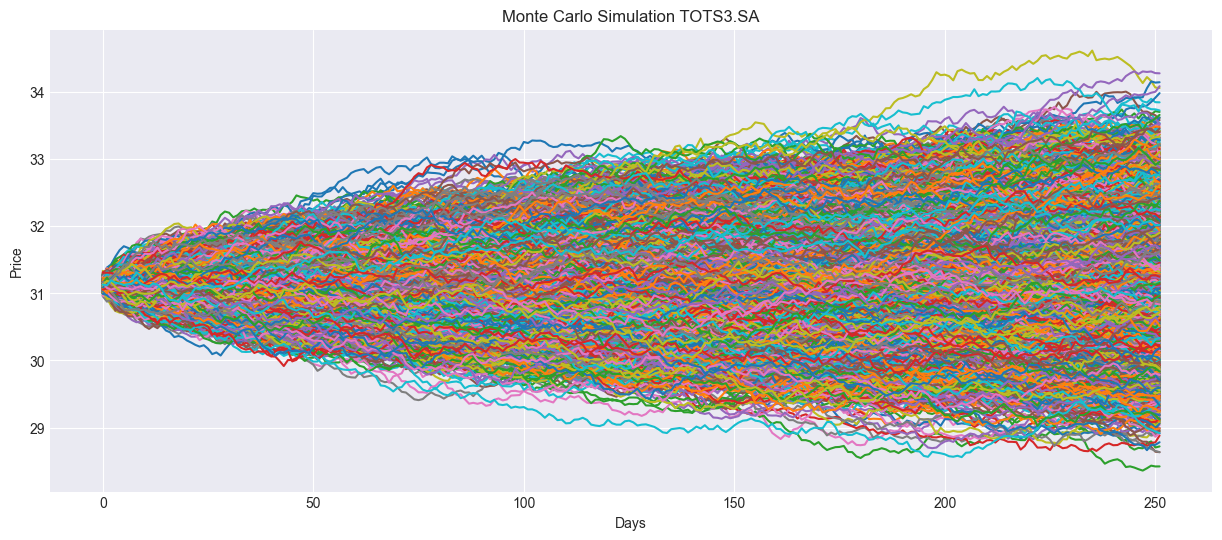

In [39]:
days = 252
sim = 10000 # Law of Large Numbers
paths = np.zeros((days, sim))
dt = 1/252

for i in range(sim):
    prices = [price] 
    for j in range(days): 
        Z = np.random.normal() # Generates a random value from a standard normal distribution N(0,1)
        next_price = prices[-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z) #GBM       
        prices.append(float(next_price))
    paths[:, i] = prices[1:]

mean_path = np.mean(paths, axis=1)

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(paths)
ax1.set_xlabel('Days')
ax1.set_ylabel('Price')
ax1.set_title(f'Monte Carlo Simulation {ticker}')

interval = 21
for day in range(0, days, interval):
    val_at_day = mean_path[day]

# plt.tight_layout()
plt.style.use('seaborn-v0_8-darkgrid')
plt.show()

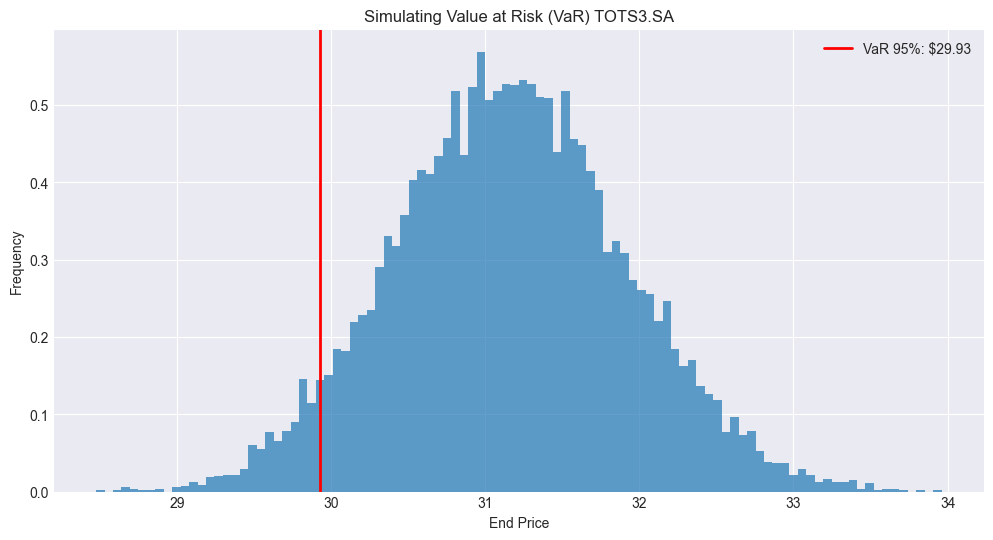

95% chance that price is > $29.93


In [32]:
end_prices = paths[-1, :]

var_95 = np.percentile(end_prices, 5)

plt.figure(figsize=(12,6))
plt.hist(end_prices, bins=100, alpha=0.7, density=True)

plt.axvline(var_95, color='r', linestyle='-', linewidth=2, label=f'VaR 95%: ${var_95:.2f}')

plt.title(f"Simulating Value at Risk (VaR) {ticker}")
plt.xlabel("End Price")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(f"95% chance that price is > ${var_95:.2f}")

In [33]:
range_min = min(end_prices)
range_max = max(end_prices)
num_bins = 25

bins = np.linspace(range_min, range_max, num_bins)
hist, _ = np.histogram(end_prices, bins=bins)
percentages = (hist / len(end_prices)) * 100

print("Prob Distribution Table\n")

for i in range(len(bins)-1):
    if percentages[i] > 5:   # since percentages are already in %
        print(f"Price Range ${bins[i]:.2f} - ${bins[i+1]:.2f}: {percentages[i]:.2f}%")

Prob Distribution Table

Price Range $30.08 - $30.30: 5.13%
Price Range $30.30 - $30.53: 7.69%
Price Range $30.53 - $30.76: 9.58%
Price Range $30.76 - $30.99: 11.69%
Price Range $30.99 - $31.22: 11.87%
Price Range $31.22 - $31.45: 11.83%
Price Range $31.45 - $31.68: 10.52%
Price Range $31.68 - $31.90: 7.94%
Price Range $31.90 - $32.13: 5.96%
